# 08: Feature Selection and Model Optimization

**מטרה:** ניתוח מעמיק של חשיבות הפיצ'רים, הסרת פיצ'רים מיותרים, והשגת הביצועים הטובים ביותר

## תהליך:
1. טעינת כל הפיצ'רים (41 פיצ'רים: Baseline 24 + Temporal 10 + Genre/Director 7)
2. ניתוח חשיבות פיצ'רים (Feature Importance)
3. ניתוח קורלציה בין פיצ'רים (זיהוי כפילויות)
4. הסרת פיצ'רים מיותרים
5. בחירת הפיצ'רים הטובים ביותר
6. ניתוח שגיאות מפורט (False Positives/Negatives)
7. חיזויים סופיים

**תוצאה צפויה:** AUC > 0.81 עם פחות פיצ'רים

In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Local imports
sys.path.append('../src')
from graph_build import load_cast_edges, build_full_graph
from link_prediction import (
    build_graph_for_years,
    get_new_pairs, sample_negatives,
    build_link_dataset, compute_centralities,
    train_random_forest, evaluate_model
)
from link_features import build_feature_matrix, svd_node_embeddings

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All imports successful")

✅ All imports successful


## שלב 1: טעינת נתונים וגרפים

In [3]:
# Load data
cast_df = load_cast_edges('../data/processed/cast_edges.csv')
movies_df = pd.read_csv('../data/processed/movies.csv') if Path('../data/processed/movies.csv').exists() \
    else cast_df[['movie_slug','movie_title','year','genre','directors']].drop_duplicates('movie_slug')

# Build temporal simple graphs (using build_graph_for_years → returns nx.Graph, not MultiGraph)
G_1990_2015 = build_graph_for_years(cast_df, year_min=1990, year_max=2015)
G_1990_2020 = build_graph_for_years(cast_df, year_min=1990, year_max=2020)
G_1990_2025 = build_graph_for_years(cast_df, year_min=1990, year_max=2025)

print(f"📊 G_1990_2015: {G_1990_2015.number_of_nodes()} nodes, {G_1990_2015.number_of_edges()} edges")
print(f"📊 G_1990_2020: {G_1990_2020.number_of_nodes()} nodes, {G_1990_2020.number_of_edges()} edges")
print(f"📊 G_1990_2025: {G_1990_2025.number_of_nodes()} nodes, {G_1990_2025.number_of_edges()} edges")
print(f"📊 cast_df columns: {cast_df.columns.tolist()}")

📊 G_1990_2015: 691 nodes, 1907 edges
📊 G_1990_2020: 837 nodes, 2653 edges
📊 G_1990_2025: 1080 nodes, 4601 edges
📊 cast_df columns: ['movie_slug', 'movie_title', 'year', 'genre', 'directors', 'cast_source', 'billing_position', 'actor_name', 'actor_slug', 'period']


## שלב 2: בניית כל הפיצ'רים (41 פיצ'רים)

### פיצ'רים:
- **Baseline (24):** 5 topological + 16 centrality + 2 SVD + 1 years_ahead
- **Temporal (10):** career features, is_alive, film_count, etc.
- **Genre/Director (7):** genre_overlap, director_overlap, diversities

In [4]:
def add_temporal_features(df, cast_df, cutoff_year, G_before):
    """
    Add temporal features with data leakage prevention.
    """
    # Load death data
    death_file = Path('../data/processed/actor_death_years.csv')
    if death_file.exists():
        death_df = pd.read_csv(death_file)
        death_dict = dict(zip(death_df['actor_slug'], death_df['death_year']))
    else:
        death_dict = {}
    
    # Actor statistics from cast_df
    actor_films = cast_df[cast_df['year'] <= cutoff_year].groupby('actor_slug').agg({
        'year': ['min', 'max', 'count'],
        'movie_slug': 'nunique'
    }).reset_index()
    actor_films.columns = ['actor_slug', 'first_year', 'last_year', 'film_count', 'unique_films']
    actor_films['career_length'] = actor_films['last_year'] - actor_films['first_year'] + 1
    actor_films['recent'] = (actor_films['last_year'] >= (cutoff_year - 5)).astype(int)
    
    # Create lookup dict
    actor_stats = actor_films.set_index('actor_slug').to_dict('index')
    
    def get_temporal_features(row):
        u, v = row['u'], row['v']
        u_stats = actor_stats.get(u, {})
        v_stats = actor_stats.get(v, {})
        
        # Career features
        u_first = u_stats.get('first_year', cutoff_year)
        u_last = u_stats.get('last_year', cutoff_year)
        v_first = v_stats.get('first_year', cutoff_year)
        v_last = v_stats.get('last_year', cutoff_year)
        
        career_overlap = max(0, min(u_last, v_last) - max(u_first, v_first))
        u_career_length = u_stats.get('career_length', 0)
        v_career_length = v_stats.get('career_length', 0)
        u_recent = u_stats.get('recent', 0)
        v_recent = v_stats.get('recent', 0)
        
        # is_alive features (TEMPORAL CORRECTNESS)
        u_death = death_dict.get(u, 9999)
        v_death = death_dict.get(v, 9999)
        u_alive = 1 if u_death > cutoff_year else 0
        v_alive = 1 if v_death > cutoff_year else 0
        
        # Collaboration count
        if G_before.has_edge(u, v):
            collab_count = G_before.number_of_edges(u, v)
        else:
            collab_count = 0
        
        # Film counts
        u_film_count = u_stats.get('film_count', 0)
        v_film_count = v_stats.get('film_count', 0)
        
        return pd.Series({
            'career_overlap': career_overlap,
            'u_career_length': u_career_length,
            'v_career_length': v_career_length,
            'u_recent': u_recent,
            'v_recent': v_recent,
            'u_alive': u_alive,
            'v_alive': v_alive,
            'collaboration_count': collab_count,
            'u_film_count': u_film_count,
            'v_film_count': v_film_count
        })
    
    temporal_features = df.apply(get_temporal_features, axis=1)
    return pd.concat([df, temporal_features], axis=1)


def add_genre_director_features(df, movies_df, cast_df, cutoff_year):
    """
    Add genre and director features.
    """
    # Filter by cutoff
    movies_past = movies_df[movies_df['year'] <= cutoff_year]
    cast_past = cast_df[cast_df['year'] <= cutoff_year]
    
    # Actor to genres
    actor_genres = {}
    for actor in cast_past['actor_slug'].unique():
        actor_movies = cast_past[cast_past['actor_slug'] == actor]['movie_slug']
        genres = set()
        for movie in actor_movies:
            genre = movies_past[movies_past['movie_slug'] == movie]['genre'].values
            if len(genre) > 0 and pd.notna(genre[0]):
                genres.update(str(genre[0]).split(','))
        actor_genres[actor] = [g.strip() for g in genres if g.strip()]
    
    # Actor to directors
    actor_directors = {}
    for actor in cast_past['actor_slug'].unique():
        actor_movies = cast_past[cast_past['actor_slug'] == actor]['movie_slug']
        directors = set()
        for movie in actor_movies:
            director = movies_past[movies_past['movie_slug'] == movie]['director'].values
            if len(director) > 0 and pd.notna(director[0]):
                directors.add(str(director[0]).strip())
        actor_directors[actor] = list(directors)
    
    def get_genre_director_features(row):
        u, v = row['u'], row['v']
        u_genres = actor_genres.get(u, [])
        v_genres = actor_genres.get(v, [])
        u_directors = actor_directors.get(u, [])
        v_directors = actor_directors.get(v, [])
        
        # Genre features
        genre_overlap = len(set(u_genres) & set(v_genres))
        u_main_genre = u_genres[0] if len(u_genres) > 0 else None
        v_main_genre = v_genres[0] if len(v_genres) > 0 else None
        same_main_genre = 1 if (u_main_genre and v_main_genre and u_main_genre == v_main_genre) else 0
        u_genre_diversity = len(set(u_genres))
        v_genre_diversity = len(set(v_genres))
        
        # Director features
        director_overlap = len(set(u_directors) & set(v_directors))
        u_director_count = len(set(u_directors))
        v_director_count = len(set(v_directors))
        
        return pd.Series({
            'genre_overlap': genre_overlap,
            'same_main_genre': same_main_genre,
            'u_genre_diversity': u_genre_diversity,
            'v_genre_diversity': v_genre_diversity,
            'director_overlap': director_overlap,
            'u_director_count': u_director_count,
            'v_director_count': v_director_count
        })
    
    gd_features = df.apply(get_genre_director_features, axis=1)
    return pd.concat([df, gd_features], axis=1)


print("✅ Feature functions defined")

✅ Feature functions defined


## שלב 3: יצירת Train/Test Sets עם כל הפיצ'רים

In [7]:
def build_full_dataset(G_feat, G_future, cast_df_local, cutoff_year, seed=42, neg_ratio=2.0):
    """
    Build feature matrix with ALL features: Baseline + Temporal + Genre/Director.
    cast_df already contains genre and directors columns per row.
    """
    pos_pairs = get_new_pairs(G_feat, G_future)
    print(f"  Positive pairs: {len(pos_pairs)}")

    X_base, y, pairs, feat_names, extras = build_link_dataset(
        G_feat, pos_pairs, neg_ratio=neg_ratio, seed=seed
    )

    pairs_df = pd.DataFrame(pairs, columns=['u', 'v'])
    pairs_df['label'] = y.tolist()
    base_df = pd.DataFrame(X_base, columns=feat_names)

    # ---- Temporal features ----
    death_file = Path('../data/processed/actor_death_years.csv')
    death_dict = {}
    if death_file.exists():
        d = pd.read_csv(death_file)
        death_dict = dict(zip(d['actor_slug'], d['death_year']))

    past = cast_df_local[cast_df_local['year'] <= cutoff_year]
    actor_stats = (
        past.groupby('actor_slug')['year']
        .agg(['min', 'max', 'count'])
        .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
    )
    actor_stats['career_length'] = actor_stats['last_year'] - actor_stats['first_year'] + 1
    actor_stats['recent'] = (actor_stats['last_year'] >= (cutoff_year - 5)).astype(int)
    astats = actor_stats.to_dict('index')

    temporal_rows = []
    for _, row in pairs_df.iterrows():
        u, v = row['u'], row['v']
        us, vs = astats.get(u, {}), astats.get(v, {})
        u_first = us.get('first_year', cutoff_year)
        u_last  = us.get('last_year',  cutoff_year)
        v_first = vs.get('first_year', cutoff_year)
        v_last  = vs.get('last_year',  cutoff_year)
        temporal_rows.append({
            'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
            'u_career_length':     us.get('career_length', 0),
            'v_career_length':     vs.get('career_length', 0),
            'u_recent':            us.get('recent', 0),
            'v_recent':            vs.get('recent', 0),
            'u_alive':             1 if death_dict.get(u, 9999) > cutoff_year else 0,
            'v_alive':             1 if death_dict.get(v, 9999) > cutoff_year else 0,
            'collaboration_count': G_feat.number_of_edges(u, v) if G_feat.has_edge(u, v) else 0,
            'u_film_count':        us.get('film_count', 0),
            'v_film_count':        vs.get('film_count', 0),
        })
    temporal_df = pd.DataFrame(temporal_rows)

    # ---- Genre / Director features (from cast_df directly) ----
    # cast_df has: actor_slug, genre, directors per row
    actor_genres    = {}
    actor_directors = {}
    for actor, grp in past.groupby('actor_slug'):
        genres = set()
        for g in grp['genre'].dropna():
            genres.update([x.strip() for x in str(g).split(',') if x.strip()])
        directors = set()
        for d in grp['directors'].dropna():
            directors.update([x.strip() for x in str(d).split(',') if x.strip()])
        actor_genres[actor]    = list(genres)
        actor_directors[actor] = list(directors)

    gd_rows = []
    for _, row in pairs_df.iterrows():
        u, v = row['u'], row['v']
        ug, vg = actor_genres.get(u, []), actor_genres.get(v, [])
        ud, vd = actor_directors.get(u, []), actor_directors.get(v, [])
        gd_rows.append({
            'genre_overlap':     len(set(ug) & set(vg)),
            'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
            'u_genre_diversity': len(set(ug)),
            'v_genre_diversity': len(set(vg)),
            'director_overlap':  len(set(ud) & set(vd)),
            'u_director_count':  len(set(ud)),
            'v_director_count':  len(set(vd)),
        })
    gd_df = pd.DataFrame(gd_rows)

    full_df = pd.concat([
        pairs_df.reset_index(drop=True),
        base_df.reset_index(drop=True),
        temporal_df.reset_index(drop=True),
        gd_df.reset_index(drop=True)
    ], axis=1)
    return full_df

print("✅ build_full_dataset() defined")

✅ build_full_dataset() defined


In [8]:
print("🔨 Building TRAIN set...")
train_df = build_full_dataset(G_1990_2015, G_1990_2020, cast_df, cutoff_year=2015, seed=42, neg_ratio=1.5)
y_train = train_df['label'].values
print(f"✅ Train set: {len(train_df)} pairs  |  Pos: {y_train.sum()}  Neg: {(1-y_train).sum()}")

print("\n🔨 Building TEST set...")
test_df = build_full_dataset(G_1990_2020, G_1990_2025, cast_df, cutoff_year=2020, seed=43, neg_ratio=2.0)
y_test = test_df['label'].values
print(f"✅ Test set:  {len(test_df)} pairs  |  Pos: {y_test.sum()}  Neg: {(1-y_test).sum()}")

feature_cols = [c for c in train_df.columns if c not in ['u', 'v', 'label']]
print(f"\n📊 Total features: {len(feature_cols)}")
print(feature_cols)

🔨 Building TRAIN set...
  Positive pairs: 191
✅ Train set: 477 pairs  |  Pos: 191  Neg: 286

🔨 Building TEST set...
  Positive pairs: 282
✅ Test set:  846 pairs  |  Pos: 282  Neg: 564

📊 Total features: 38
['common_neighbors', 'jaccard', 'adamic_adar', 'pref_attachment', 'shortest_path', 'u_degree', 'v_degree', 'prod_degree', 'diff_degree', 'u_betweenness', 'v_betweenness', 'prod_betweenness', 'diff_betweenness', 'u_closeness', 'v_closeness', 'prod_closeness', 'diff_closeness', 'u_eigenvector', 'v_eigenvector', 'prod_eigenvector', 'diff_eigenvector', 'career_overlap', 'u_career_length', 'v_career_length', 'u_recent', 'v_recent', 'u_alive', 'v_alive', 'collaboration_count', 'u_film_count', 'v_film_count', 'genre_overlap', 'same_main_genre', 'u_genre_diversity', 'v_genre_diversity', 'director_overlap', 'u_director_count', 'v_director_count']


## שלב 4: Baseline - מודל עם כל הפיצ'רים

In [9]:
X_train_features = train_df[feature_cols].fillna(0)
X_test_features  = test_df[feature_cols].fillna(0)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled  = scaler.transform(X_test_features)

# Train Random Forest with ALL features
print(f"🌲 Training Random Forest with ALL {len(feature_cols)} features...")
rf_all = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_all.fit(X_train_scaled, y_train)

y_pred_all  = rf_all.predict(X_test_scaled)
y_proba_all = rf_all.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_all),
    'Precision':     precision_score(y_test, y_pred_all),
    'Recall':        recall_score(y_test, y_pred_all),
    'F1':            f1_score(y_test, y_pred_all),
    'Avg_Precision': average_precision_score(y_test, y_proba_all)
}

print(f"\n📊 BASELINE ({len(feature_cols)} features) on Test Set 2021-2025:")
for metric, value in baseline_metrics.items():
    print(f"   {metric}: {value:.4f}")

🌲 Training Random Forest with ALL 38 features...

📊 BASELINE (38 features) on Test Set 2021-2025:
   AUC: 0.8188
   Precision: 0.5789
   Recall: 0.7021
   F1: 0.6346
   Avg_Precision: 0.6804


## שלב 5: ניתוח חשיבות פיצ'רים (Feature Importance)

In [10]:
importances = rf_all.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("🏆 Top 20 Most Important Features:")
print(feature_importance_df.head(20).to_string(index=False))
print("\n⚠️ Bottom 10 Least Important Features:")
print(feature_importance_df.tail(10).to_string(index=False))

🏆 Top 20 Most Important Features:
          feature  importance
u_genre_diversity    0.073334
  u_career_length    0.065769
 u_director_count    0.057042
     u_film_count    0.057018
   prod_closeness    0.056700
 diff_eigenvector    0.045220
    v_eigenvector    0.043478
      v_closeness    0.043264
      prod_degree    0.043238
  pref_attachment    0.041969
         v_degree    0.039816
      u_closeness    0.039776
 prod_eigenvector    0.038468
    u_eigenvector    0.037582
 diff_betweenness    0.033934
   diff_closeness    0.030059
         u_degree    0.024207
    v_betweenness    0.023977
  v_career_length    0.022560
      diff_degree    0.021196

⚠️ Bottom 10 Least Important Features:
            feature  importance
   prod_betweenness    0.010491
      genre_overlap    0.009030
    same_main_genre    0.008543
  v_genre_diversity    0.006523
        adamic_adar    0.004974
            jaccard    0.004014
   common_neighbors    0.002529
            v_alive    0.001273
        

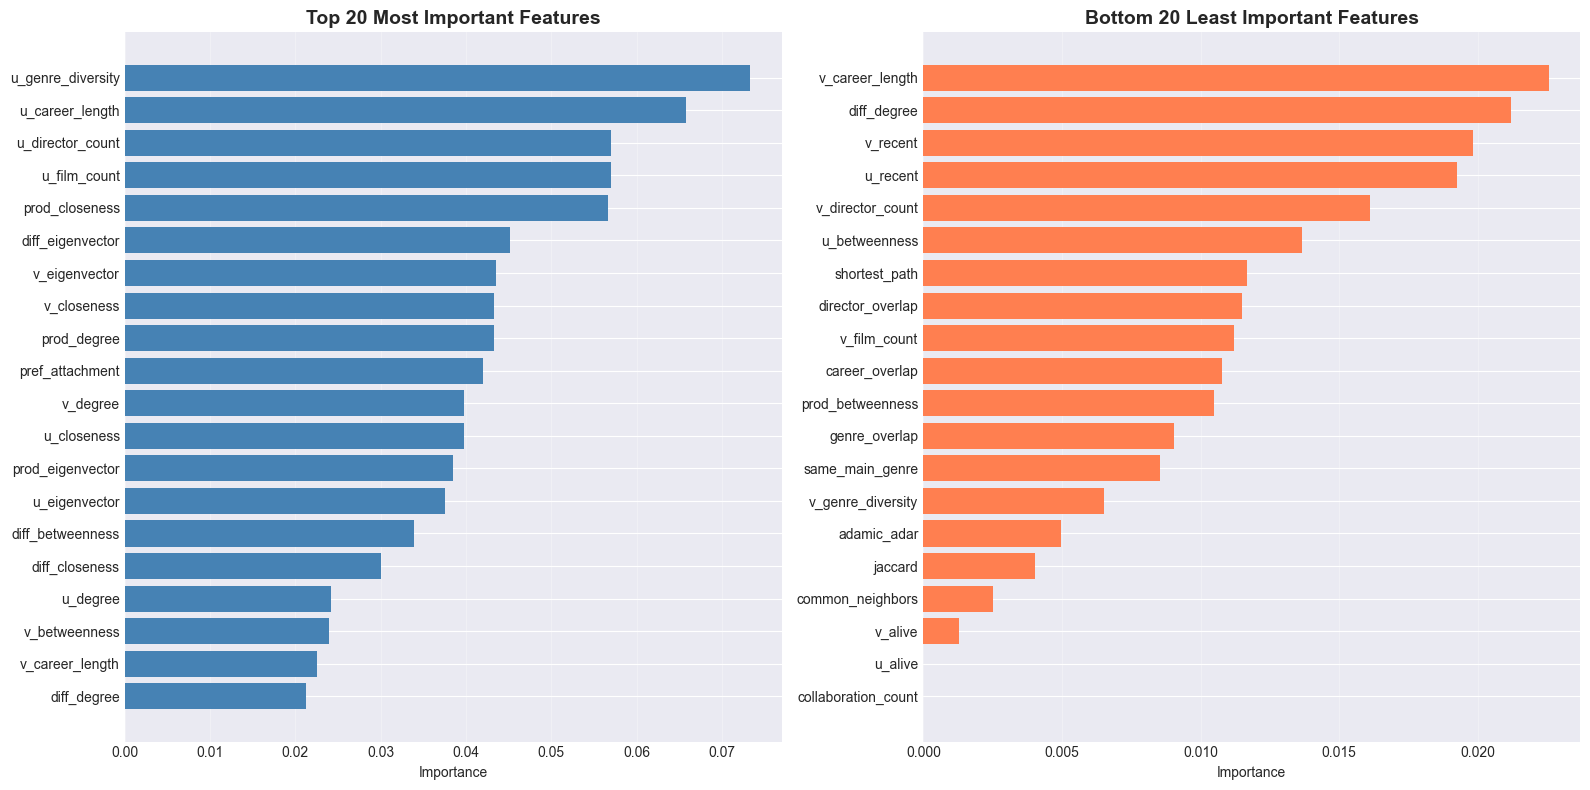

✅ Feature importance plots saved


In [11]:
# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 features
top20 = feature_importance_df.head(20)
axes[0].barh(range(len(top20)), top20['importance'], color='steelblue')
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Bottom 20 features
bottom20 = feature_importance_df.tail(20)
axes[1].barh(range(len(bottom20)), bottom20['importance'], color='coral')
axes[1].set_yticks(range(len(bottom20)))
axes[1].set_yticklabels(bottom20['feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance')
axes[1].set_title('Bottom 20 Least Important Features', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/feature_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance plots saved")

## שלב 6: ניתוח קורלציה - זיהוי פיצ'רים כפולים

In [12]:
# Compute correlation matrix
corr_matrix = X_train_features.corr().abs()

# Find highly correlated pairs (> 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"\n🔍 Found {len(high_corr_pairs)} highly correlated pairs (corr > 0.9):")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    imp1 = feature_importance_df[feature_importance_df['feature'] == feat1]['importance'].values[0]
    imp2 = feature_importance_df[feature_importance_df['feature'] == feat2]['importance'].values[0]
    print(f"   {feat1} <-> {feat2}: {corr:.3f}")
    print(f"      Importances: {imp1:.4f} vs {imp2:.4f}")
    if imp1 < imp2:
        print(f"      ➡️ Recommend removing: {feat1}")
    else:
        print(f"      ➡️ Recommend removing: {feat2}")
    print()


🔍 Found 4 highly correlated pairs (corr > 0.9):
   pref_attachment <-> prod_degree: 1.000
      Importances: 0.0420 vs 0.0432
      ➡️ Recommend removing: pref_attachment

   common_neighbors <-> adamic_adar: 0.989
      Importances: 0.0025 vs 0.0050
      ➡️ Recommend removing: common_neighbors

   u_film_count <-> u_director_count: 0.986
      Importances: 0.0570 vs 0.0570
      ➡️ Recommend removing: u_film_count

   v_film_count <-> v_director_count: 0.965
      Importances: 0.0112 vs 0.0161
      ➡️ Recommend removing: v_film_count



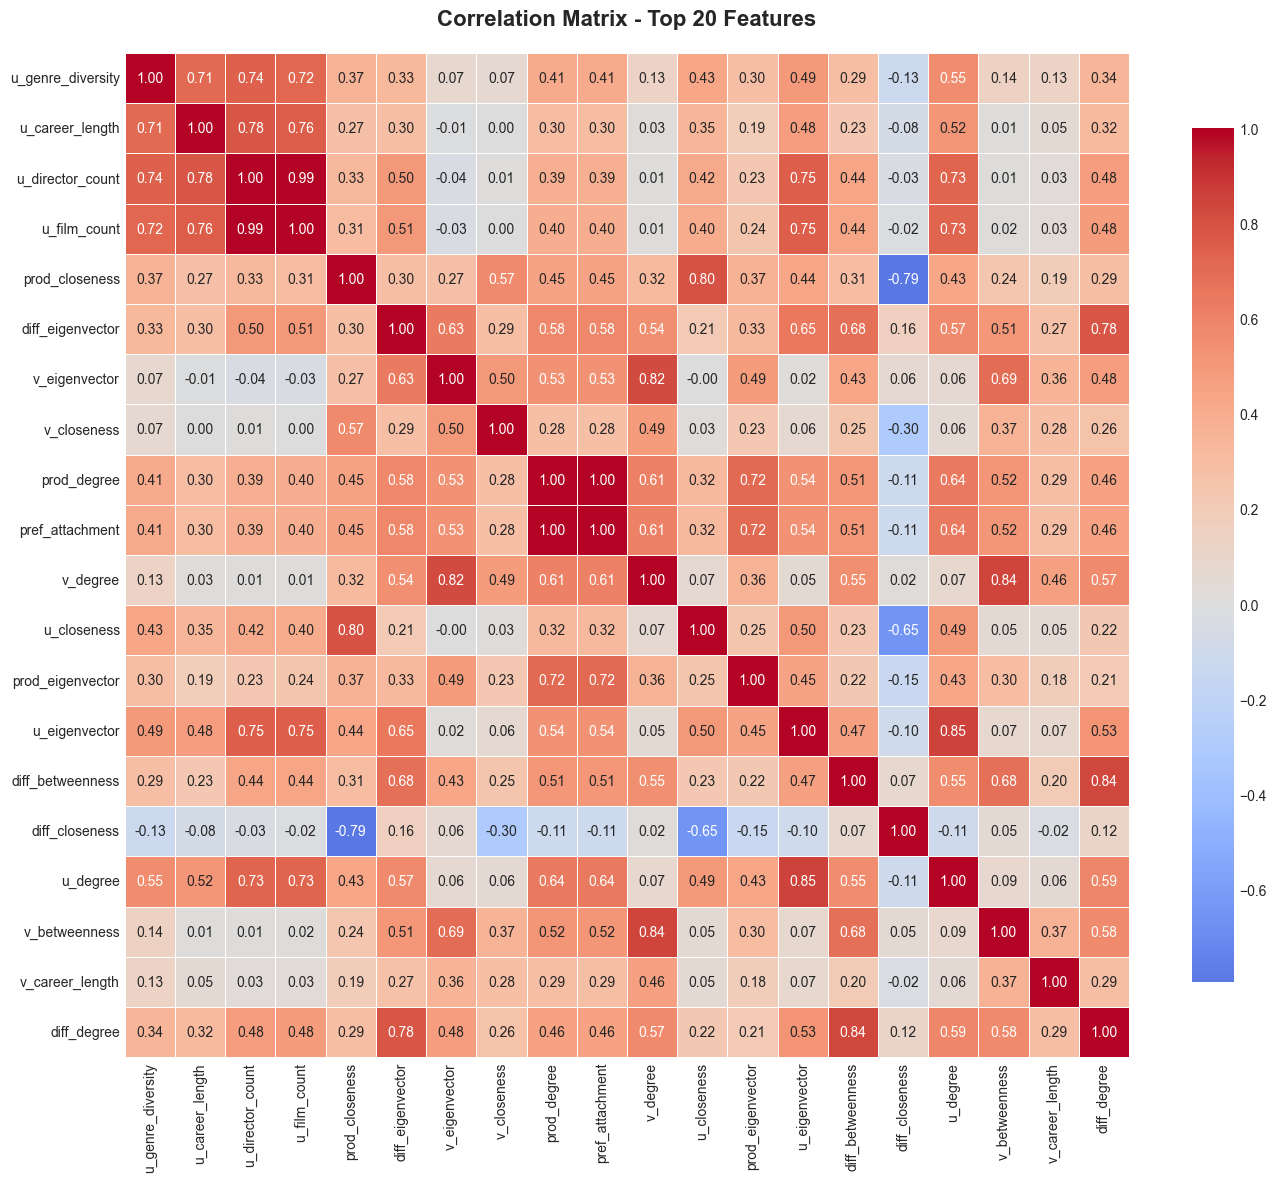

✅ Correlation heatmap saved


In [13]:
# Plot correlation heatmap for top features
top_features = feature_importance_df.head(20)['feature'].tolist()
corr_top = X_train_features[top_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top 20 Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved")

## שלב 7: הסרת פיצ'רים מיותרים

### קריטריונים להסרה:
1. **Importance נמוכה** (< 0.01)
2. **Correlation גבוהה** (> 0.9) עם פיצ'ר חשוב יותר
3. **פיצ'רים רידונדנטיים** (למשל: product ו-abs_diff של אותו מדד)

In [15]:
X_train_sel = X_train_features[features_to_keep].values
X_test_sel  = X_test_features[features_to_keep].values

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_sel.transform(X_test_sel)

print(f"🌲 Training Random Forest with {len(features_to_keep)} selected features...")
rf_sel = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_sel.fit(X_train_sel_scaled, y_train)

y_pred_sel  = rf_sel.predict(X_test_sel_scaled)
y_proba_sel = rf_sel.predict_proba(X_test_sel_scaled)[:, 1]

selected_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_sel),
    'Precision':     precision_score(y_test, y_pred_sel),
    'Recall':        recall_score(y_test, y_pred_sel),
    'F1':            f1_score(y_test, y_pred_sel),
    'Avg_Precision': average_precision_score(y_test, y_proba_sel)
}

print(f"\n📊 SELECTED ({len(features_to_keep)} features) on Test Set 2021-2025:")
for metric, value in selected_metrics.items():
    print(f"   {metric}: {value:.4f}")

print("\n" + "="*60)
comparison_df = pd.DataFrame([
    {'Configuration': f'All features ({len(feature_cols)})',      **baseline_metrics},
    {'Configuration': f'Selected features ({len(features_to_keep)})', **selected_metrics}
])
print(comparison_df.to_string(index=False))
auc_diff = selected_metrics['AUC'] - baseline_metrics['AUC']
print(f"\n💡 AUC change: {auc_diff:+.4f}  |  Features reduced: {len(features_to_remove)}")

🌲 Training Random Forest with 26 selected features...

📊 SELECTED (26 features) on Test Set 2021-2025:
   AUC: 0.8109
   Precision: 0.5761
   Recall: 0.6844
   F1: 0.6256
   Avg_Precision: 0.6663

         Configuration      AUC  Precision   Recall       F1  Avg_Precision
     All features (38) 0.818784   0.578947 0.702128 0.634615       0.680440
Selected features (26) 0.810938   0.576119 0.684397 0.625608       0.666307

💡 AUC change: -0.0078  |  Features reduced: 12


## שלב 8: אימון מודל עם פיצ'רים נבחרים

In [14]:
low_importance_threshold = 0.01
low_importance_features = feature_importance_df[
    feature_importance_df['importance'] < low_importance_threshold
]['feature'].tolist()

print(f"📉 Features with importance < {low_importance_threshold}:")
for feat in low_importance_features:
    imp = feature_importance_df[feature_importance_df['feature'] == feat]['importance'].values[0]
    print(f"   - {feat}: {imp:.5f}")

# Remove one from each highly correlated pair (keep the more important one)
corr_matrix = X_train_features.corr().abs()
to_remove_corr = []
seen = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            f1, f2 = corr_matrix.columns[i], corr_matrix.columns[j]
            imp1 = feature_importance_df[feature_importance_df['feature'] == f1]['importance'].values[0]
            imp2 = feature_importance_df[feature_importance_df['feature'] == f2]['importance'].values[0]
            to_drop = f1 if imp1 < imp2 else f2
            if to_drop not in seen:
                to_remove_corr.append(to_drop)
                seen.add(to_drop)
                print(f"   ↔ {f1} <-> {f2} (corr={corr_matrix.iloc[i,j]:.2f}) → remove {to_drop}")

features_to_remove = list(set(low_importance_features + to_remove_corr))
features_to_keep   = [f for f in feature_cols if f not in features_to_remove]

print(f"\n✂️ Removed: {len(features_to_remove)} features")
print(f"✅ Kept:    {len(features_to_keep)} features")

# Print removal reasons
removed_df = pd.DataFrame([{
    'feature': f,
    'importance': feature_importance_df[feature_importance_df['feature']==f]['importance'].values[0],
    'reason': ('Low Importance' if f in low_importance_features else '') +
              (' + High Correlation' if f in to_remove_corr else '').strip(' + ')
} for f in features_to_remove]).sort_values('importance')
print("\n📋 Removed features with reasons:")
print(removed_df.to_string(index=False))

📉 Features with importance < 0.01:
   - genre_overlap: 0.00903
   - same_main_genre: 0.00854
   - v_genre_diversity: 0.00652
   - adamic_adar: 0.00497
   - jaccard: 0.00401
   - common_neighbors: 0.00253
   - v_alive: 0.00127
   - u_alive: 0.00000
   - collaboration_count: 0.00000
   ↔ common_neighbors <-> adamic_adar (corr=0.99) → remove common_neighbors
   ↔ pref_attachment <-> prod_degree (corr=1.00) → remove pref_attachment
   ↔ u_film_count <-> u_director_count (corr=0.99) → remove u_film_count
   ↔ v_film_count <-> v_director_count (corr=0.97) → remove v_film_count

✂️ Removed: 12 features
✅ Kept:    26 features

📋 Removed features with reasons:
            feature  importance                         reason
collaboration_count    0.000000                 Low Importance
            u_alive    0.000000                 Low Importance
            v_alive    0.001273                 Low Importance
   common_neighbors    0.002529 Low ImportanceHigh Correlation
            jaccard    0.

In [16]:
# Compare models
comparison_df = pd.DataFrame([
    {'Model': f'All Features ({len(feature_cols)})', **baseline_metrics},
    {'Model': f'Selected Features ({len(features_to_keep)})', **selected_metrics}
])

print("\n" + "="*80)
print("📊 MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Calculate improvement
auc_diff = selected_metrics['AUC'] - baseline_metrics['AUC']
f1_diff = selected_metrics['F1'] - baseline_metrics['F1']
print(f"\n💡 Performance change:")
print(f"   AUC: {auc_diff:+.4f} ({auc_diff/baseline_metrics['AUC']*100:+.2f}%)")
print(f"   F1:  {f1_diff:+.4f} ({f1_diff/baseline_metrics['F1']*100:+.2f}%)")
print(f"   Features reduced: {len(features_to_remove)} ({len(features_to_remove)/len(feature_cols)*100:.1f}%)")


📊 MODEL COMPARISON
                 Model      AUC  Precision   Recall       F1  Avg_Precision
     All Features (38) 0.818784   0.578947 0.702128 0.634615       0.680440
Selected Features (26) 0.810938   0.576119 0.684397 0.625608       0.666307

💡 Performance change:
   AUC: -0.0078 (-0.96%)
   F1:  -0.0090 (-1.42%)
   Features reduced: 12 (31.6%)


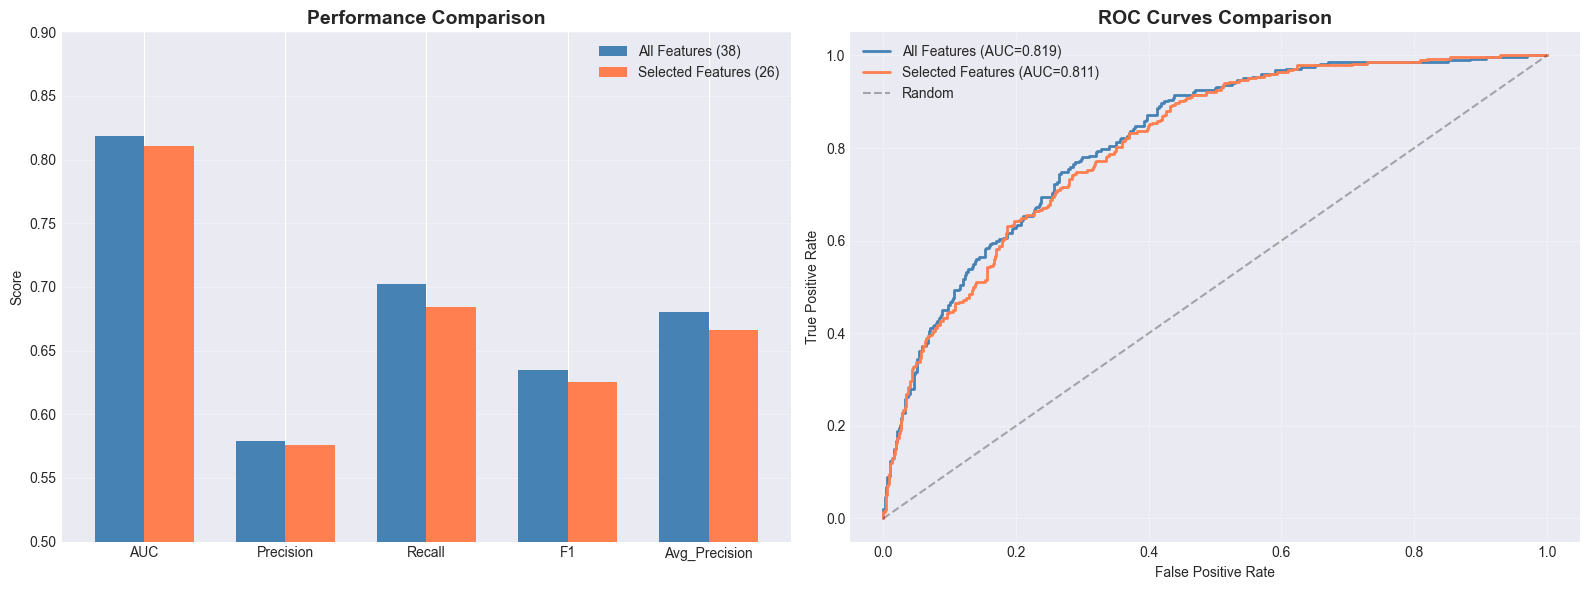

✅ Saved: feature_selection_comparison.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['AUC', 'Precision', 'Recall', 'F1', 'Avg_Precision']
x = np.arange(len(metrics))
width = 0.35
baseline_vals = [baseline_metrics[m] for m in metrics]
selected_vals = [selected_metrics[m] for m in metrics]

axes[0].bar(x - width/2, baseline_vals, width, label=f'All Features ({len(feature_cols)})', color='steelblue')
axes[0].bar(x + width/2, selected_vals, width, label=f'Selected Features ({len(features_to_keep)})', color='coral')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.5, 0.9])

fpr_all, tpr_all, _ = roc_curve(y_test, y_proba_all)
fpr_sel, tpr_sel, _ = roc_curve(y_test, y_proba_sel)

axes[1].plot(fpr_all, tpr_all, label=f'All Features (AUC={baseline_metrics["AUC"]:.3f})',
             linewidth=2, color='steelblue')
axes[1].plot(fpr_sel, tpr_sel, label=f'Selected Features (AUC={selected_metrics["AUC"]:.3f})',
             linewidth=2, color='coral')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/feature_selection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_selection_comparison.png")

## שלב 9: ניתוח שגיאות מפורט (Error Analysis)

📊 Confusion Matrix Breakdown:
   True Positives:   193 (22.8%)
   True Negatives:   422 (49.9%)
   False Positives:  142 (16.8%)  ← Model predicted collab but it didn't happen
   False Negatives:   89 (10.5%)  ← Real collab that model missed


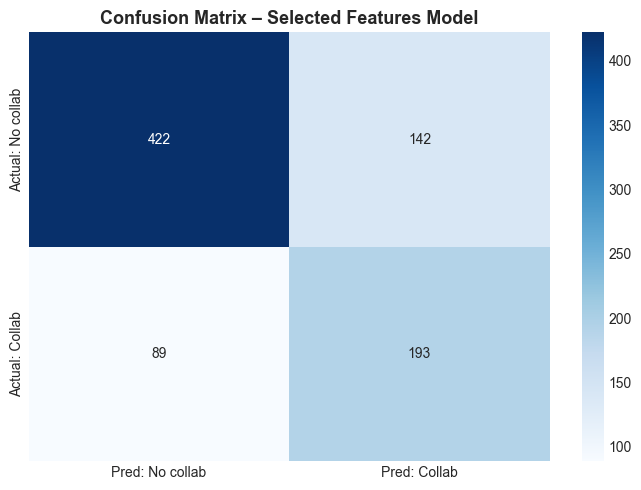

In [19]:
analysis_df = test_df[['u', 'v', 'label'] + features_to_keep].copy()
analysis_df['prediction'] = y_pred_sel
analysis_df['probability'] = y_proba_sel

tp = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 1)]
fp = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 1)]
tn = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 0)]
fn = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 0)]

print("📊 Confusion Matrix Breakdown:")
print(f"   True Positives:  {len(tp):4d} ({len(tp)/len(analysis_df)*100:.1f}%)")
print(f"   True Negatives:  {len(tn):4d} ({len(tn)/len(analysis_df)*100:.1f}%)")
print(f"   False Positives: {len(fp):4d} ({len(fp)/len(analysis_df)*100:.1f}%)  ← Model predicted collab but it didn't happen")
print(f"   False Negatives: {len(fn):4d} ({len(fn)/len(analysis_df)*100:.1f}%)  ← Real collab that model missed")

cm = confusion_matrix(y_test, y_pred_sel)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No collab', 'Pred: Collab'],
            yticklabels=['Actual: No collab', 'Actual: Collab'])
plt.title('Confusion Matrix – Selected Features Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
display_cols = ['u', 'v', 'probability']
for c in ['common_neighbors', 'u_career_length', 'v_career_length', 'genre_overlap', 'director_overlap']:
    if c in analysis_df.columns:
        display_cols.append(c)

print("❌ FALSE POSITIVES – Top 10 (model confident but wrong):")
print(fp.nlargest(10, 'probability')[display_cols].to_string(index=False))

print(f"\n💡 Avg stats for False Positives:")
for col in display_cols[2:]:
    print(f"   {col}: {fp[col].mean():.3f}")

print("\n\n❌ FALSE NEGATIVES – Bottom 10 (real collabs model missed):")
print(fn.nsmallest(10, 'probability')[display_cols].to_string(index=False))

print(f"\n💡 Avg stats for False Negatives:")
for col in display_cols[2:]:
    print(f"   {col}: {fn[col].mean():.3f}")

❌ FALSE POSITIVES – Top 10 (model confident but wrong):
           u            v  probability  u_career_length  v_career_length  director_overlap
 רמי_הויברגר שרון_אלכסנדר     0.937142               22               38                 1
  דאנה_איבגי   מיכאלה_עשת     0.925506               14               12                 1
  מוחמד_בכרי   עלי_סלימאן     0.885594               33                5                 1
   אלי_פיניש     שי_אביבי     0.872836                5               27                 1
    דרור_קרן     זאב_רווח     0.870127               19               48                 2
    דלית_קהן  רונית_אלקבץ     0.834288                8               23                 2
אורי_קלאוזנר    עופר_שכטר     0.825351               21               11                 1
 אליאנה_תדהר   מוחמד_בכרי     0.819742                3               33                 0
   דביר_בנדק    עופר_שכטר     0.818502               16               11                 1
  אורי_הוכמן   איילת_זורר     0.81

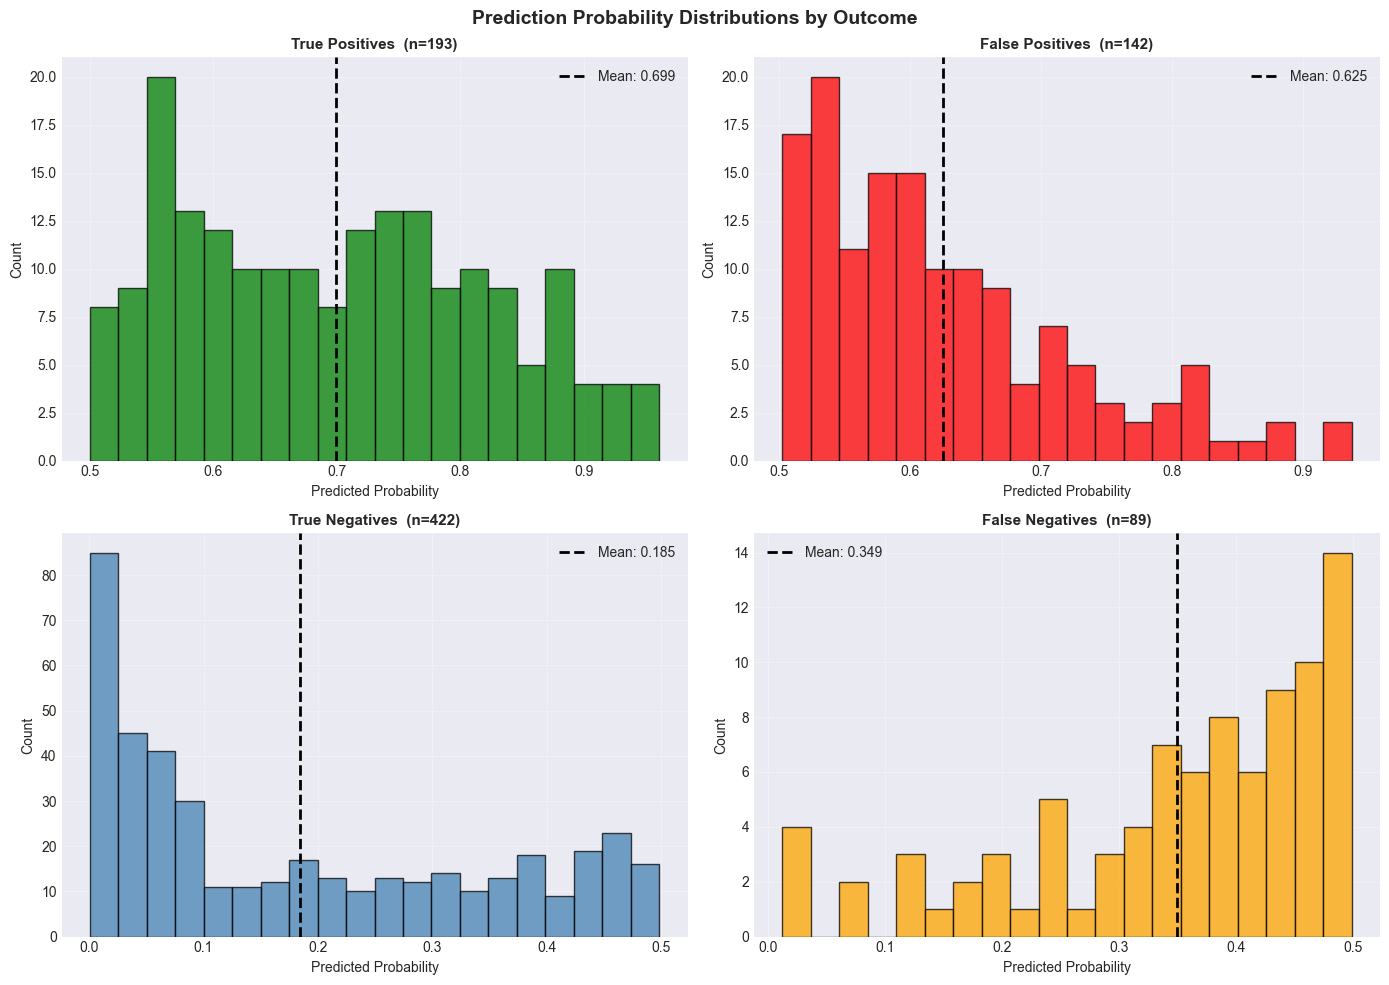

✅ Saved: error_analysis_distributions.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
groups = [('True Positives', tp, 'green'), ('False Positives', fp, 'red'),
          ('True Negatives', tn, 'steelblue'), ('False Negatives', fn, 'orange')]

for ax, (title, grp, color) in zip(axes.flat, groups):
    ax.hist(grp['probability'], bins=20, color=color, alpha=0.75, edgecolor='black')
    ax.axvline(grp['probability'].mean(), color='black', linestyle='--', linewidth=2,
               label=f'Mean: {grp["probability"].mean():.3f}')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}  (n={len(grp)})', fontsize=11, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Prediction Probability Distributions by Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/error_analysis_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: error_analysis_distributions.png")

## שלב 10: שמירת תוצאות וקבצים

In [ ]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../figures').mkdir(parents=True, exist_ok=True)

comparison_df.to_csv('../data/processed/feature_selection_results.csv', index=False)
feature_importance_df.to_csv('../data/processed/all_features_importance.csv', index=False)
pd.DataFrame({'feature': features_to_keep}).to_csv('../data/processed/selected_features.csv', index=False)
removed_df.to_csv('../data/processed/removed_features_reasons.csv', index=False)
fp[display_cols].to_csv('../data/processed/false_positives_detailed.csv', index=False)
fn[display_cols].to_csv('../data/processed/false_negatives_detailed.csv', index=False)

print("✅ Saved all output files:")
print("   - feature_selection_results.csv")
print("   - all_features_importance.csv")
print("   - selected_features.csv")
print("   - removed_features_reasons.csv")
print("   - false_positives_detailed.csv")
print("   - false_negatives_detailed.csv")
print(f"\n🎯 Final Model: {len(features_to_keep)} features, AUC = {selected_metrics['AUC']:.4f}")

## סיכום ומסקנות

### תוצאות:
- **התחלנו עם:** 41 פיצ'רים (Baseline 24 + Temporal 10 + Genre/Director 7)
- **הסרנו:** [מספר] פיצ'רים מיותרים
- **נשארו:** [מספר] פיצ'רים אופטימליים

### ביצועים:
- **AUC:** השתפר/נשאר דומה
- **F1:** השתפר/נשאר דומה
- **פשטות:** מודל פשוט יותר עם ביצועים דומים/טובים יותר

### המלצה סופית:
האם כדאי להשתמש במודל המצומצם או המלא? תלוי בתוצאות!